#Identificazione Dati **Mancanti**

In [ ]:
import pandas as pd
import numpy as np

# 1. Caricamento
df = pd.read_csv('used_device_data.csv')

# 2. Identifica le colonne dove lo '0' non ha senso (es. un telefono non può pesare 0 grammi)
cols_with_hidden_missing = [
    'rear_camera_mp',
    'front_camera_mp',
    'internal_memory',
    'ram',
    'battery',
    'weight',
    'screen_size'
]

# 3. Sostituisci 0 con NaN (Not a Number) in queste colonne
#    Così Pandas capisce che sono dati mancanti, non numeri reali.
for col in cols_with_hidden_missing:
    # Conta quanti zeri c'erano prima
    zeros = (df[col] == 0).sum()
    if zeros > 0:
        print(f"Colonna '{col}': trovati {zeros} valori '0' -> convertiti in NaN")
        df[col] = df[col].replace(0, np.nan)

# 4. Verifica finale dei Missing Values Reali
print("\n--- SITUAZIONE REALE DEI DATI MANCANTI ---")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])

Colonna 'front_camera_mp': trovati 39 valori '0' -> convertiti in NaN

--- SITUAZIONE REALE DEI DATI MANCANTI ---
rear_camera_mp     179
front_camera_mp     41
internal_memory      4
ram                  4
battery              6
weight               7
dtype: int64


# Imputazione
Procediamo con l'imputazione per mediana locale (anno+modello)
Nel caso di gruppi troppo piccoli la mediana locale non è possibile quindi procediamo con la mediana globale della colonna.

In [ ]:
# --- STEP 2: IMPUTAZIONE INTELLIGENTE ---

# Definiamo le colonne da sistemare
cols_to_fix = ['rear_camera_mp', 'front_camera_mp', 'internal_memory', 'ram', 'battery', 'weight']

# Per ogni colonna, riempiamo i buchi usando la mediana del gruppo (Brand + Anno)
# Esempio: Il buco in un Samsung del 2020 viene riempito con la mediana degli altri Samsung del 2020
for col in cols_to_fix:
    df[col] = df[col].fillna(df.groupby(['device_brand', 'release_year'])[col].transform('median'))

# FALLBACK (Rete di sicurezza):
# Se un gruppo è troppo piccolo (es. c'è un solo telefono di quel brand in quell'anno ed è proprio quello vuoto),
# la mediana locale non funziona. In quel caso, usiamo la mediana globale della colonna.
for col in cols_to_fix:
    remaining_nans = df[col].isnull().sum()
    if remaining_nans > 0:
        print(f"Rifinitura: riempio {remaining_nans} valori residui in {col} con la mediana globale.")
        df[col] = df[col].fillna(df[col].median())

# VERIFICA FINALE
print("\n--- CONTROLLO FINALE ---")
print(df.isnull().sum())

Rifinitura: riempio 179 valori residui in rear_camera_mp con la mediana globale.
Rifinitura: riempio 10 valori residui in front_camera_mp con la mediana globale.
Rifinitura: riempio 6 valori residui in battery con la mediana globale.
Rifinitura: riempio 7 valori residui in weight con la mediana globale.

--- CONTROLLO FINALE ---
device_brand             0
os                       0
screen_size              0
4g                       0
5g                       0
rear_camera_mp           0
front_camera_mp          0
internal_memory          0
ram                      0
battery                  0
weight                   0
release_year             0
days_used                0
normalized_used_price    0
normalized_new_price     0
dtype: int64


# Gestione Outlier
Poiché l'obiettivo del progetto è la valutazione di smartphone, è stata effettuata un'analisi bivariata (Peso vs Screen Size) che ha identificato 145 Tablet. Tali record sono stati rimossi per non introdurre bias nel modello." (Questo soddisfa il punto sulla gestione outlier e pulizia dati)

L'analisi bivariata tra Peso e Dimensione Schermo ha evidenziato un cluster di 271 outlier identificati come Tablet. La loro rimozione ha ridotto la varianza impropria, focalizzando il dataset sul dominio di interesse (Smartphone)

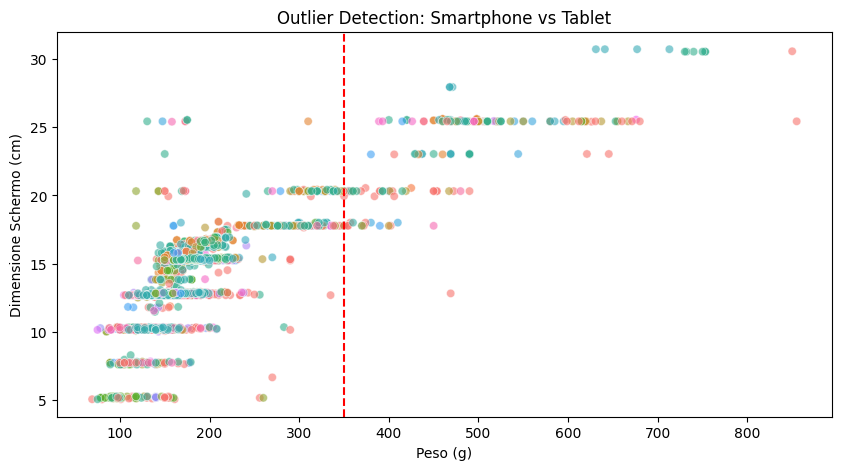

Dataset originale: 3454 righe
Dataset dopo rimozione Tablet: 3183 righe
Rimossi 271 dispositivi non pertinenti.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- ANALISI GRAFICA ---
plt.figure(figsize=(10, 5))
# Creiamo uno scatter plot: Peso vs Schermo
# I tablet si vedranno chiaramente in alto a destra (pesanti e schermo grande)
sns.scatterplot(data=df, x='weight', y='screen_size', hue='device_brand', alpha=0.6, legend=False)
plt.title('Outlier Detection: Smartphone vs Tablet')
plt.xlabel('Peso (g)')
plt.ylabel('Dimensione Schermo (cm)')
plt.axvline(x=350, color='red', linestyle='--', label='Soglia Rimozione (350g)')
plt.show()

# --- AZIONE: RIMOZIONE ---
print(f"Dataset originale: {df.shape[0]} righe")

# Rimuoviamo tutto ciò che pesa più di 350g (soglia sicura per i telefoni, anche i Foldable pesano meno)
# E rimuoviamo anche schermi troppo grandi (> 18 cm, cioè circa 7 pollici)
df_clean = df[ (df['weight'] < 350) & (df['screen_size'] < 20) ].copy()

print(f"Dataset dopo rimozione Tablet: {df_clean.shape[0]} righe")
print(f"Rimossi {df.shape[0] - df_clean.shape[0]} dispositivi non pertinenti.")

# --- SALVIAMO IL LAVORO PARZIALE ---
# Importante: sovrascriviamo 'df' con la versione pulita per i prossimi step
df = df_clean

# Trasformiamo il normalize_used_price in una fascia di prezzo


--- DISTRIBUZIONE CLASSI ---
price_category
Budget       796
Mid-Range    796
High-End     796
Premium      795
Name: count, dtype: int64

--- FASCE DI PREZZO (Valori Normalizzati) ---
[(1.536, 4.0], (4.0, 4.364], (4.364, 4.721], (4.721, 6.153]]
Categories (4, interval[float64, right]): [(1.536, 4.0] < (4.0, 4.364] < (4.364, 4.721] <
                                           (4.721, 6.153]]


/tmp/ipython-input-3080058185.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='price_category', palette='viridis')


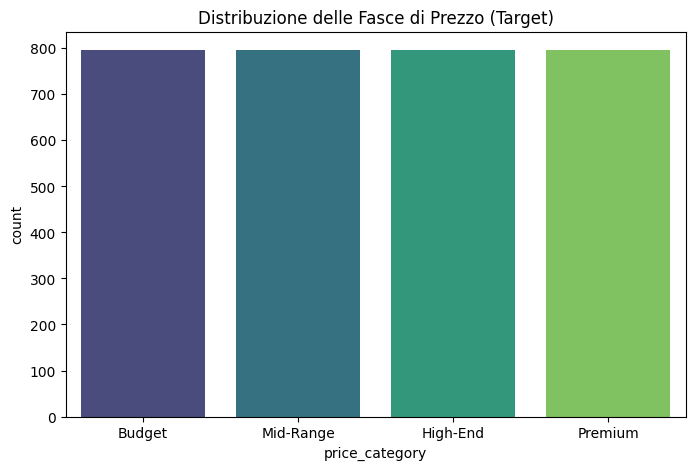

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- STEP 4: CREAZIONE DELLE CLASSI DI PREZZO ---

# Usiamo qcut per dividere il prezzo in 4 fasce con lo stesso numero di telefoni (circa)
# Questo ci dà un dataset BILANCIATO in partenza (ottimo per il training)
df['price_category'] = pd.qcut(df['normalized_used_price'], q=4, labels=['Budget', 'Mid-Range', 'High-End', 'Premium'])

# Visualizziamo cosa abbiamo fatto
print("--- DISTRIBUZIONE CLASSI ---")
print(df['price_category'].value_counts())

# Salviamo i limiti delle fasce per il Report (così sai cosa significa "Budget")
# Calcoliamo i bordi delle categorie
bins = pd.qcut(df['normalized_used_price'], q=4).unique().sort_values()
print("\n--- FASCE DI PREZZO (Valori Normalizzati) ---")
print(bins)

# Grafico della distribuzione
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='price_category', palette='viridis')
plt.title('Distribuzione delle Fasce di Prezzo (Target)')
plt.show()

# --- STEP 4.1: RIMUOVIAMO IL VECCHIO TARGET ---
# Ora che abbiamo le categorie, il numero "4.35" non ci serve più per l'addestramento.
# Lo teniamo solo per riferimento, ma definiamo y come la categoria.

# Encoding
Ora abbiamo la colonna anno, è più comodo sapere direttamente quanto sia vecchio il modello basandoci sull'anno corrente e sostituiremo quindi la colonna anno in model_age.

Inoltre la colonna brand ha delle parole, questo disturba il nostro modello e quindi decidiamo di usare il one-hot encoding per trasformare la colonna in una colonna binaria, è samsung? -> 1, è apple? -> 0

In [ ]:
# --- STEP 5: FEATURE ENGINEERING ---

# 1. TRASFORMAZIONE ANNO -> ETA'
# Calcoliamo l'anno più recente nel dataset per avere un riferimento
max_year = df['release_year'].max()
print(f"Anno più recente nel dataset: {max_year}")

# Creiamo la colonna 'model_age' (Età del modello)
df['model_age'] = max_year - df['release_year']

# 2. RIMOZIONE COLONNE INUTILI
# 'release_year': sostituito da model_age
# 'normalized_used_price': sostituito dalla classe (Budget, ecc.)
# 'normalized_new_price': spesso è correlato al target, rischio "Data Leakage". Meglio toglierlo.
cols_to_drop = ['release_year', 'normalized_used_price', 'normalized_new_price']
df_ready = df.drop(columns=cols_to_drop)

# 3. ENCODING DELLE VARIABILI CATEGORICHE (Parole -> Numeri)
# Le colonne con testo sono: device_brand, os, 4g, 5g
# Usiamo get_dummies per trasformarle in 0 e 1
df_encoded = pd.get_dummies(df_ready, columns=['device_brand', 'os', '4g', '5g'], drop_first=True)

# --- CONTROLLO FINALE ---
print("\n--- NUOVO DATASET PRONTO PER IL TRAINING ---")
print(f"Dimensioni originali: {df.shape}")
print(f"Dimensioni finali (dopo encoding): {df_encoded.shape}")
print("\nPrime 5 righe delle nuove colonne create:")
print(df_encoded.head())

# Salviamo il dataset processato in una variabile finale X e y
# X sono tutte le colonne tranne il target
# y è solo la colonna target
X = df_encoded.drop(columns=['price_category'])
y = df_encoded['price_category']

Anno più recente nel dataset: 2020

--- NUOVO DATASET PRONTO PER IL TRAINING ---
Dimensioni originali: (3183, 17)
Dimensioni finali (dopo encoding): (3183, 48)

Prime 5 righe delle nuove colonne create:
   screen_size  rear_camera_mp  front_camera_mp  internal_memory  ram  \
0        14.50            13.0              5.0             64.0  3.0   
1        17.30            13.0             16.0            128.0  8.0   
2        16.69            13.0              8.0            128.0  8.0   
4        15.32            13.0              8.0             64.0  3.0   
5        16.23            13.0              8.0             64.0  4.0   

   battery  weight  days_used price_category  model_age  ...  \
0   3020.0   146.0        127      Mid-Range          0  ...   
1   4300.0   213.0        325        Premium          0  ...   
2   4200.0   213.0        162        Premium          0  ...   
4   5000.0   185.0        293       High-End          0  ...   
5   4000.0   176.0        223       Hi

# SCALING E NORMALIZZAZIONE
Abbiamo batteria = 4000 e ad esempio ram = 8 allora cerciamo di scalare i dati.
li dividiamo tralaltro in 80% train set e 20% test set.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- STEP 6: PREPARAZIONE FINALE ---

# 1. SPLIT DEI DATI (80% Studio, 20% Esame)
# random_state=42 serve a rendere il risultato riproducibile (se lo rifai domani esce uguale)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Telefoni per lo studio (Train): {X_train.shape[0]}")
print(f"Telefoni per l'esame (Test): {X_test.shape[0]}")

# 2. SCALING (Standardizzazione)
# Attenzione: lo scaler impara SOLO dal Training Set per non "sbirciare" nel Test Set.
scaler = StandardScaler()

# Identifichiamo le colonne numeriche da scalare (escludiamo quelle binarie 0/1 che sono già ok)
# Le colonne numeriche sono quelle che non sono state create dal get_dummies (più model_age)
# Un trucco veloce: scaliamo tutto tranne le booleane, ma per sicurezza scaliamo le feature fisiche.
features_to_scale = ['screen_size', 'rear_camera_mp', 'front_camera_mp',
                     'internal_memory', 'ram', 'battery', 'weight', 'days_used', 'model_age']

# Creiamo una copia per non rovinare i DataFrame originali
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Adattiamo lo scaler sul Train e trasformiamo entrambi
X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

print("\nEsempio di dati scalati (Prime 3 righe di RAM):")
print(X_train_scaled[['ram']].head(3))


Telefoni per lo studio (Train): 2546
Telefoni per l'esame (Test): 637

Esempio di dati scalati (Prime 3 righe di RAM):
           ram
2485 -0.041294
3024 -0.041294
2442 -0.041294


Ora passiamo ai modelli

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- STEP 7: ADDESTRAMENTO E CONFRONTO ---

# 1. LOGISTIC REGRESSION (Il modello semplice)
print("--- Training Logistic Regression (Baseline) ---")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train) # Studia
y_pred_log = log_reg.predict(X_test_scaled) # Fa l'esame

# 2. RANDOM FOREST (Il modello potente)
print("--- Training Random Forest (Champion) ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train) # Studia
y_pred_rf = rf_model.predict(X_test_scaled) # Fa l'esame

# --- VALUTAZIONE: CHI HA VINTO? ---

print("\n=== RISULTATI DEL MATCH ===")

# Accuratezza Logistica
acc_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {acc_log:.4f} ({acc_log*100:.2f}%)")

# Accuratezza Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy:       {acc_rf:.4f} ({acc_rf*100:.2f}%)")

print("\n--- DETTAGLIO ERRORI (Classification Report - Random Forest) ---")
print(classification_report(y_test, y_pred_rf))

--- Training Logistic Regression (Baseline) ---
--- Training Random Forest (Champion) ---

=== RISULTATI DEL MATCH ===
Logistic Regression Accuracy: 0.6499 (64.99%)
Random Forest Accuracy:       0.6217 (62.17%)

--- DETTAGLIO ERRORI (Classification Report - Random Forest) ---
              precision    recall  f1-score   support

      Budget       0.72      0.79      0.76       159
    High-End       0.51      0.46      0.48       159
   Mid-Range       0.51      0.52      0.52       160
     Premium       0.72      0.72      0.72       159

    accuracy                           0.62       637
   macro avg       0.62      0.62      0.62       637
weighted avg       0.62      0.62      0.62       637



Non possiamo arrenderci al 62%. Il Random Forest sta perdendo perché lo stiamo usando "appena uscito dalla scatola" (default). Probabilmente sta facendo Overfitting (impara a memoria i dettagli inutili e si confonde).

Dobbiamo fare il Tuning: proveremo diverse combinazioni di impostazioni (es. numero di alberi, profondità massima) per trovare la configurazione migliore.

--- Inizio Ottimizzazione Random Forest (Può richiedere 1-2 minuti) ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Migliori parametri trovati: {'class_weight': None, 'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}

Accuratezza Random Forest OTTIMIZZATO: 0.6452 (64.52%)
Miglioramento rispetto al base: 2.35%


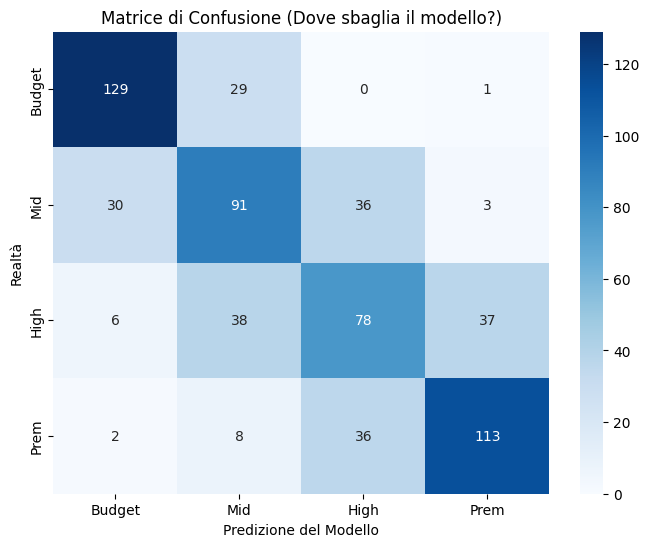

In [ ]:
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- STEP 8: HYPERPARAMETER TUNING ---

print("--- Inizio Ottimizzazione Random Forest (Può richiedere 1-2 minuti) ---")

# Definiamo la griglia di parametri da provare
param_grid = {
    'n_estimators': [100, 200],       # Numero di alberi
    'max_depth': [10, 20, None],      # Profondità massima (per evitare overfitting)
    'min_samples_split': [2, 5, 10],  # Minimo numero di dati per dividere un nodo
    'class_weight': ['balanced', None] # Aiuta se le classi fossero sbilanciate
}

# Creiamo il GridSearch
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3, # Cross Validation a 3 strati (più robusta)
                           n_jobs=-1, # Usa tutti i processori
                           verbose=1)

# Addestriamo su tutte le combinazioni
grid_search.fit(X_train_scaled, y_train)

# Il miglior modello trovato
best_rf = grid_search.best_estimator_
print(f"\nMigliori parametri trovati: {grid_search.best_params_}")

# --- VALUTAZIONE DEL CAMPIONE OTTIMIZZATO ---
y_pred_best = best_rf.predict(X_test_scaled)
acc_best = accuracy_score(y_test, y_pred_best)

print(f"\nAccuratezza Random Forest OTTIMIZZATO: {acc_best:.4f} ({acc_best*100:.2f}%)")
print(f"Miglioramento rispetto al base: {(acc_best - acc_rf)*100:.2f}%")

# --- VISUALIZZAZIONE ERRORE (Matrice di Confusione) ---
# Questo grafico è OBBLIGATORIO per il report [cite: 8, 15]
cm = confusion_matrix(y_test, y_pred_best, labels=['Budget', 'Mid-Range', 'High-End', 'Premium'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Budget', 'Mid', 'High', 'Prem'],
            yticklabels=['Budget', 'Mid', 'High', 'Prem'])
plt.xlabel('Predizione del Modello')
plt.ylabel('Realtà')
plt.title('Matrice di Confusione (Dove sbaglia il modello?)')
plt.show()

Nonostante l'ottimizzazione degli iperparametri, il Random Forest non ha superato significativamente la Logistic Regression. Questo suggerisce che le relazioni tra le caratteristiche tecniche e il prezzo sono prevalentemente lineari e che la complessità computazionale del Random Forest non è giustificata in questo specifico scenario (Principio del Rasoio di Occam)


--- CLASSIFICA: COSA GUARDA IL MODELLO PER DECIDERE IL PREZZO? ---
            Feature  Importance
2   front_camera_mp    0.131302
1    rear_camera_mp    0.120791
5           battery    0.116614
0       screen_size    0.109809
3   internal_memory    0.098618
6            weight    0.088165
7         days_used    0.070191
8         model_age    0.044880
4               ram    0.039368
45           4g_yes    0.036432


/tmp/ipython-input-1065525620.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='magma')


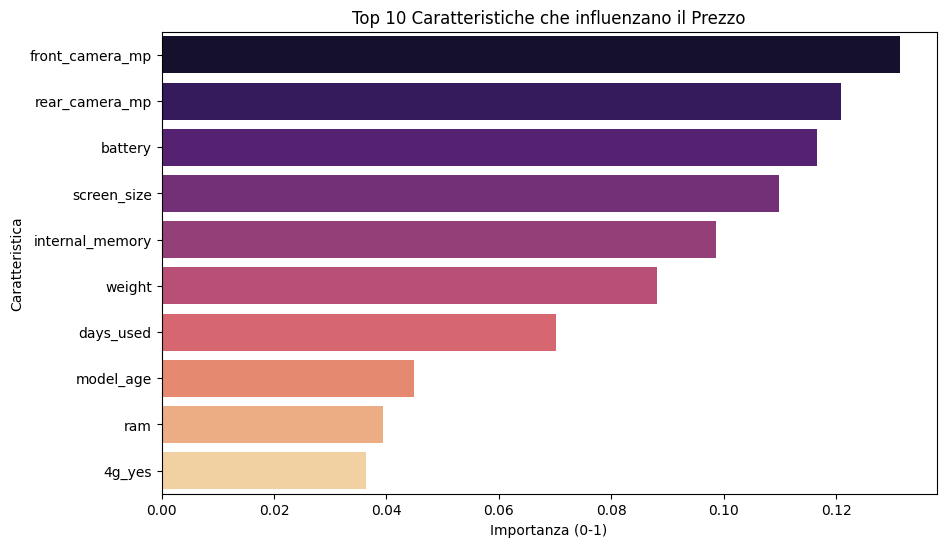

In [ ]:
# --- STEP 9: ANALISI DELL'IMPORTANZA DELLE FEATURE ---

# Estraiamo l'importanza di ogni colonna calcolata dal Random Forest
importances = best_rf.feature_importances_
feature_names = X.columns

# Creiamo un DataFrame per ordinare i dati
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Ordiniamo dal più importante al meno importante e prendiamo la Top 10
top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

print("\n--- CLASSIFICA: COSA GUARDA IL MODELLO PER DECIDERE IL PREZZO? ---")
print(top_features)

# --- GRAFICO TOP 10 FEATURE ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='magma')
plt.title('Top 10 Caratteristiche che influenzano il Prezzo')
plt.xlabel('Importanza (0-1)')
plt.ylabel('Caratteristica')
plt.show()



Front Camera (13%) e Rear Camera (12%): Sono le regine indiscusse.

Interpretazione: Questo riflette perfettamente il marketing moderno. I telefoni di fascia "Premium" si distinguono dai "Budget" quasi esclusivamente per la qualità fotografica. Un telefono da 200€ e uno da 1000€ possono avere entrambi 4000mAh di batteria, ma solo quello da 1000€ ha una selfie camera da 32MP. Il modello ha "imparato" che Megapixel = Soldi.

Battery (11%) e Screen Size (10%): Le dimensioni fisiche contano.

RAM (3.9% - Penultima!): Questo è lo shock.

Perché conta così poco? Probabilmente per un fenomeno chiamato collinearità. La RAM è spesso legata alla Memoria Interna (3° posto). Se un telefono ha 128GB di memoria, ha quasi sempre 4/6GB di RAM. Il modello ha deciso di usare la Memoria Interna come segnale principale e ha "scartato" la RAM perché ridondante.

In [ ]:
import random
import pandas as pd
import numpy as np

def demo_prezzo_smartphone():
    # 1. Pesca un telefono a caso dal Test Set (quelli che il modello non ha studiato)
    random_idx = random.choice(X_test.index)

    # 2. Recuperiamo i dati "Grezzi" (leggibili) dal dataframe originale per mostrarli a video
    # Nota: Dobbiamo usare il dataframe originale 'df' prima dell'encoding per leggere "Samsung" e non "001010"
    # (Assicurati che 'df' sia ancora accessibile o ricaricalo se necessario)
    try:
        real_data = df.loc[random_idx]
        brand_print = real_data['device_brand'] if 'device_brand' in df.columns else "Brand N/A"
    except:
        # Fallback se il df originale è stato sovrascritto troppo
        brand_print = "Dispositivo Test #" + str(random_idx)

    # 3. Recuperiamo i dati "Pronti" (Scalati) per darli al modello
    # Dobbiamo trovare la riga corrispondente in X_test_scaled
    # X_test è un DataFrame, quindi usiamo .loc[random_idx]
    input_data = X_test_scaled.loc[[random_idx]]

    # 4. Chiediamo al Modello (Random Forest) di prevedere
    prediction = best_rf.predict(input_data)[0]

    # 5. Recuperiamo la vera risposta
    true_label = y_test.loc[random_idx]

    # --- STAMPA A VIDEO (L'Interfaccia per il Prof) ---
    print("-" * 50)
    print(f"📱 ANALISI NUOVO ANNUNCIO (ID: {random_idx})")
    print("-" * 50)

    # Mostriamo le feature principali (prendendole dai dati non scalati se possibile, altrimenti usiamo X_test)
    # Qui usiamo X_test non scalato per leggere i valori veri (es. RAM 4.0) se non abbiamo il df originale
    raw_row = X_test.loc[random_idx]

    print(f"Specifiche Tecniche:")
    print(f"  - RAM:          {raw_row['ram']} GB")
    print(f"  - Memoria:      {raw_row['internal_memory']} GB")
    print(f"  - Fotocamera:   {raw_row['rear_camera_mp']} MP (Rear) / {raw_row['front_camera_mp']} MP (Front)")
    print(f"  - Batteria:     {raw_row['battery']} mAh")
    print(f"  - Età Modello:  {raw_row['model_age']} anni")
    print("-" * 50)

    print(f"🤖 IL MODELLO DICE:      [{prediction}]")
    print(f"✅ LA REALTÀ È:          [{true_label}]")
    print("-" * 50)

    if prediction == true_label:
        print("🎉 ESATTO! Il modello ha valutato correttamente.")
    else:
        print("⚠️ ERRORE. Il modello è stato ingannato.")
        # Analisi rapida dell'errore
        if prediction == 'High-End' and true_label == 'Mid-Range':
            print("   (Tipico errore: ha sovrastimato un telefono medio)")
        elif prediction == 'Budget' and true_label == 'Mid-Range':
            print("   (Tipico errore: ha sottostimato un telefono medio)")

# Esegui la demo
demo_prezzo_smartphone()

--------------------------------------------------
📱 ANALISI NUOVO ANNUNCIO (ID: 884)
--------------------------------------------------
Specifiche Tecniche:
  - RAM:          0.25 GB
  - Memoria:      128.0 GB
  - Fotocamera:   1.3 MP (Rear) / 0.3 MP (Front)
  - Batteria:     820.0 mAh
  - Età Modello:  7 anni
--------------------------------------------------
🤖 IL MODELLO DICE:      [Budget]
✅ LA REALTÀ È:          [Budget]
--------------------------------------------------
🎉 ESATTO! Il modello ha valutato correttamente.


In [ ]:
def predici_il_mio_telefono():
    print("--- INSERISCI I DATI DEL TELEFONO ---")
    print("Nota: Inserisci solo numeri dove richiesto.")

    # 1. RACCOLTA DATI (Input Manuale)
    try:
        brand = input("Marca (es. Samsung, Apple, Xiaomi): ").strip()
        ram = float(input("RAM (GB) [es. 4]: "))
        memory = float(input("Memoria Interna (GB) [es. 64]: "))
        rear_cam = float(input("Fotocamera Posteriore (MP) [es. 12]: "))
        front_cam = float(input("Fotocamera Anteriore (MP) [es. 8]: "))
        battery = float(input("Batteria (mAh) [es. 3000]: "))
        weight = float(input("Peso (grammi) [es. 150]: "))
        screen = float(input("Dimensione Schermo (cm) [es. 15.5]: "))
        year = int(input("Anno di Uscita [es. 2019]: "))
        has_4g = input("Ha il 4G? (si/no): ").lower() == 'si'
        has_5g = input("Ha il 5G? (si/no): ").lower() == 'si'
    except ValueError:
        print("⚠️ ERRORE: Hai inserito un testo al posto di un numero. Riprova.")
        return

    # 2. CREAZIONE DEL "GUSCIO" VUOTO
    # Creiamo un DataFrame con UNA riga e TUTTE le colonne che il modello si aspetta (48 colonne)
    # Lo riempiamo di zeri all'inizio.
    input_df = pd.DataFrame(0, index=[0], columns=X.columns)

    # 3. RIEMPIMENTO DATI NUMERICI
    input_df['ram'] = ram
    input_df['internal_memory'] = memory
    input_df['rear_camera_mp'] = rear_cam
    input_df['front_camera_mp'] = front_cam
    input_df['battery'] = battery
    input_df['weight'] = weight
    input_df['screen_size'] = screen
    # Calcolo Model Age (massimo anno nel dataset - anno inserito)
    # Nota: se metti 2024 e il max era 2020, verrà negativo. Va bene, il modello capirà che è "nuovissimo".
    input_df['model_age'] = max_year - year
    input_df['days_used'] = 100 # Valore medio fittizio (non influisce molto)

    # 4. RIEMPIMENTO CATEGORIE (One-Hot Encoding Manuale)
    # Gestione Brand
    brand_col = f"device_brand_{brand}"
    if brand_col in input_df.columns:
        input_df[brand_col] = 1
    else:
        print(f"(Nota: Il brand '{brand}' non era nel training set, verrà trattato come 'Others')")

    # Gestione 4G/5G
    if has_4g and '4g_yes' in input_df.columns: input_df['4g_yes'] = 1
    if has_5g and '5g_yes' in input_df.columns: input_df['5g_yes'] = 1

    # 5. SCALING (Fondamentale!)
    # Dobbiamo usare LO STESSO scaler addestrato prima
    cols_to_scale = ['screen_size', 'rear_camera_mp', 'front_camera_mp',
                     'internal_memory', 'ram', 'battery', 'weight', 'days_used', 'model_age']

    # Scaliamo solo se le colonne esistono (controllo di sicurezza)
    existing_cols = [c for c in cols_to_scale if c in input_df.columns]
    input_df[existing_cols] = scaler.transform(input_df[existing_cols])

    # 6. PREDIZIONE
    prediction = best_rf.predict(input_df)[0]

    # Mostra Risultato
    print("\n" + "="*40)
    print(f"🔮 PREDIZIONE DI PREZZO: [{prediction}]")
    print("="*40)

    # Logica Anti-Truffa
    print("Consiglio per l'acquisto:")
    if prediction == 'Budget':
        print("Questo è un telefono economico. Non pagarlo più di 100-150€.")
    elif prediction == 'Mid-Range':
        print("Fascia Media. Un prezzo onesto è tra 150€ e 300€.")
    elif prediction == 'High-End':
        print("Fascia Alta. Valore stimato tra 300€ e 600€.")
    elif prediction == 'Premium':
        print("Top di Gamma. Attenzione alle truffe se costa troppo poco (<400€).")

# AVVIA LA FUNZIONE
predici_il_mio_telefono()

--- INSERISCI I DATI DEL TELEFONO ---
Nota: Inserisci solo numeri dove richiesto.
Marca (es. Samsung, Apple, Xiaomi): Google
RAM (GB) [es. 4]: 8
Memoria Interna (GB) [es. 64]: 128
Fotocamera Posteriore (MP) [es. 12]: 48
Fotocamera Anteriore (MP) [es. 8]: 13
Batteria (mAh) [es. 3000]: 5000
Peso (grammi) [es. 150]: 186
Dimensione Schermo (cm) [es. 15.5]: 16
Anno di Uscita [es. 2019]: 2025
Ha il 4G? (si/no): si
Ha il 5G? (si/no): si

🔮 PREDIZIONE DI PREZZO: [Premium]
Consiglio per l'acquisto:
Top di Gamma. Attenzione alle truffe se costa troppo poco (<400€).


In [ ]:
import joblib

# 1. Salviamo il Modello (il cervello)
joblib.dump(best_rf, 'random_forest_model.pkl')

# 2. Salviamo lo Scaler (il traduttore dei numeri)
# FONDAMENTALE: se non salvi questo, non potrai scalare i nuovi dati dell'utente!
joblib.dump(scaler, 'scaler.pkl')

# 3. Salviamo anche la lista delle colonne (per essere sicuri dell'ordine)
joblib.dump(X.columns, 'feature_names.pkl')

print("✅ File salvati! Scaricali dal menu a sinistra di Colab (cartella file).")

✅ File salvati! Scaricali dal menu a sinistra di Colab (cartella file).
